# Task 3: Student Distribution and Correlation Analysis

Run the cells from top to bottom. Each section is kept separate so you can execute it one by one.

In [29]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
# Create synthetic student dataset

np.random.seed(42)

students = []

names = [
    "Aarav", "Vivaan", "Aditya", "Vihaan", "Arjun",
    "Sai", "Reyansh", "Krishna", "Ishaan", "Shaurya",
    "Aanya", "Diya", "Saanvi", "Ananya", "Pari",
    "Navya", "Anika", "Myra", "Sara", "Riya",
    "Rahul", "Rohan", "Karan", "Suresh", "Amit",
    "Nabin", "Sita", "Ram", "Hari", "Gita",
    "Prakash", "Roshan", "Bibek", "Asmita", "Nisha",
    "Sunil", "Manish", "Alina", "Pooja", "Kabir",
    "Ritika", "Yash", "Aryan", "Sneha", "Ramesh",
    "Kushal", "Deepa", "Anmol", "Rupesh", "Suman"
]

for name in names:
    study_hours = round(np.random.uniform(1, 10), 1)
    sleep_hours = round(np.random.uniform(4, 9), 1)
    attendance_pct = round(np.random.uniform(60, 100), 1)
    noise = np.random.randint(-10, 10)

    score = (
        study_hours * 7
        + attendance_pct * 0.3
        + noise
    )

    score = round(min(max(score, 0), 100), 1)
    passed = "Pass" if score >= 40 else "Fail"

    students.append([
        name,
        study_hours,
        sleep_hours,
        attendance_pct,
        score,
        passed
    ])

df = pd.DataFrame(
    students,
    columns=[
        "name",
        "study_hours",
        "sleep_hours",
        "attendance_pct",
        "score",
        "passed"
    ]
)

df.to_csv("students.csv", index=False)

print("students.csv created successfully")

students.csv created successfully


In [31]:
# Load dataset

df = pd.read_csv("clean_students_data.csv")

df.head()

,Name,Gender,Grade,Math,Science,English,Total,score,grade
0,Navya,Male,11,47.0,63.0,74.0,184,61.333333,C
1,Rohan,Female,3,16.0,77.0,8.0,101,33.666667,F
2,Myra,Male,7,74.0,12.0,72.0,158,52.666667,C
3,Ishaan,Male,3,92.0,27.0,25.0,144,48.000000,F
4,Aarav,Male,9,22.0,87.0,56.0,165,55.000000,C


In [32]:
# Print shape

print(df.shape)

(927, 9)


In [33]:
# Check missing values

print(df.isnull().sum())

Name       0
Gender     0
Grade      0
Math       0
Science    0
English    0
Total      0
score      0
grade      0
dtype: int64


In [34]:
# Missing value percentage

missing_percent = (
    df.isnull().sum() / len(df)
) * 100

print(missing_percent)

Name       0.0
Gender     0.0
Grade      0.0
Math       0.0
Science    0.0
English    0.0
Total      0.0
score      0.0
grade      0.0
dtype: float64


In [35]:
# Descriptive statistics

print(df.describe())

            Grade        Math     Science     English       Total       score
count  927.000000  927.000000  927.000000  927.000000  927.000000  927.000000
mean     6.421791   50.814455   49.593312   49.985976  150.393743   50.131248
std      3.432169   28.318195   29.165790   28.611851   50.270664   16.756888
min      1.000000    0.000000    0.000000    0.000000   13.000000    4.333333
25%      3.000000   26.500000   24.000000   25.000000  117.500000   39.166667
50%      6.000000   51.000000   50.000000   50.000000  152.000000   50.666667
75%      9.000000   74.000000   75.000000   74.000000  183.000000   61.000000
max     12.000000  100.000000  100.000000  100.000000  284.000000   94.666667


In [36]:
# Value counts of passed column

# Reload the file if this cell is run before the loading cell.
if 'passed' not in df.columns:
    df = pd.read_csv("students.csv")

print(df['passed'].value_counts())

passed
Pass    43
Fail     7
Name: count, dtype: int64


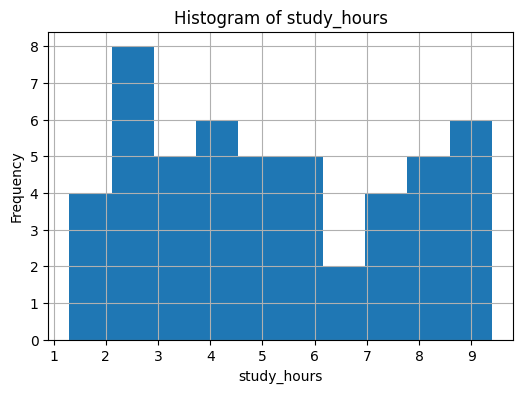

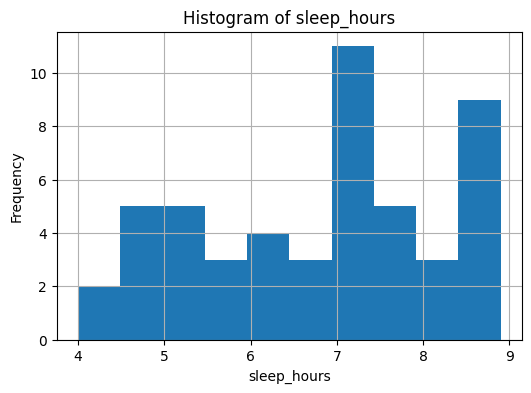

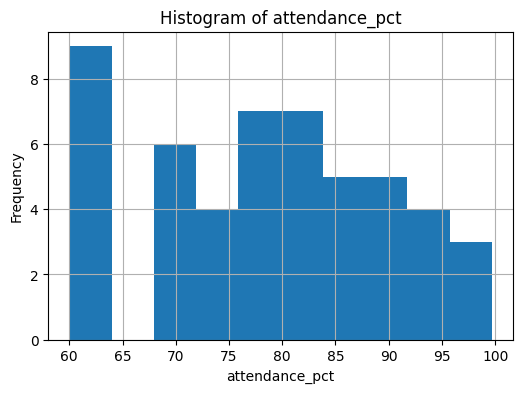

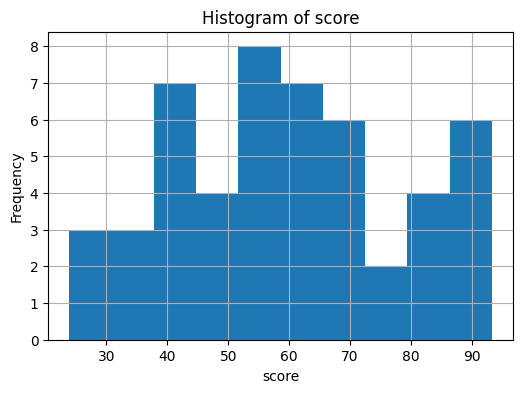

In [37]:
# Histogram for numeric columns

numeric_columns = [
    'study_hours',
    'sleep_hours',
    'attendance_pct',
    'score'
]

for col in numeric_columns:
    plt.figure(figsize=(6, 4))
    df[col].hist(bins=10)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.savefig(f"{col}_histogram.png")
    plt.show()

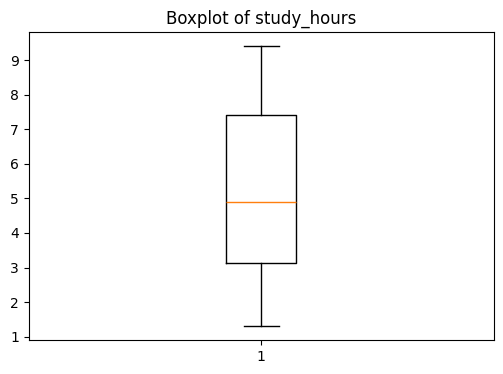

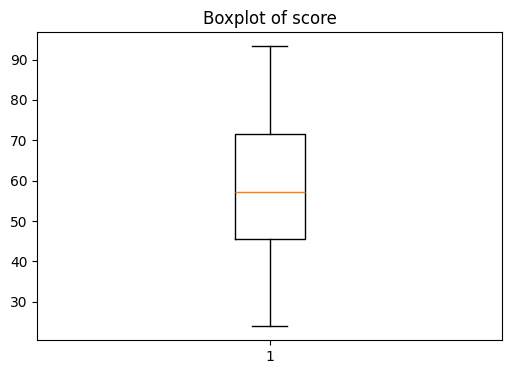

In [38]:
# Boxplot for study_hours and score

for col in ['study_hours', 'score']:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.savefig(f"{col}_boxplot.png")
    plt.show()

In [39]:
# Correlation matrix

correlation_matrix = df.corr(
    numeric_only=True
)

print(correlation_matrix)

                study_hours  sleep_hours  attendance_pct     score
study_hours        1.000000    -0.293641        0.063283  0.950581
sleep_hours       -0.293641     1.000000        0.195920 -0.253564
attendance_pct     0.063283     0.195920        1.000000  0.148854
score              0.950581    -0.253564        0.148854  1.000000


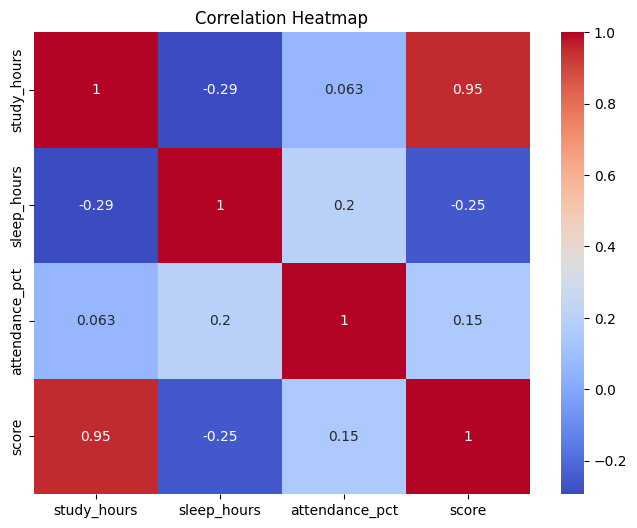

In [40]:
# Heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.savefig("heatmap.png")

plt.show()

In [41]:
# Find strongest and weakest correlations

corr_pairs = correlation_matrix.unstack()

corr_pairs = corr_pairs[
    corr_pairs != 1
]

corr_pairs = corr_pairs.sort_values(
    ascending=False
)

print("Top 3 Strongest Correlations:\n")

print(corr_pairs.head(3))

print("\nTop 3 Weakest Correlations:\n")

print(corr_pairs.tail(3))

Top 3 Strongest Correlations:

study_hours  score             0.950581
score        study_hours       0.950581
sleep_hours  attendance_pct    0.195920
dtype: float64

Top 3 Weakest Correlations:

score        sleep_hours   -0.253564
sleep_hours  study_hours   -0.293641
study_hours  sleep_hours   -0.293641
dtype: float64


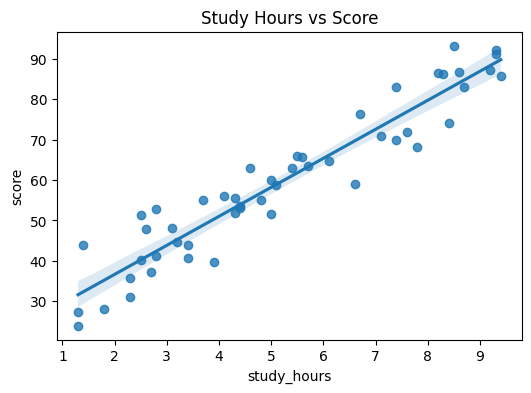

In [42]:
# Scatter plot 1

plt.figure(figsize=(6, 4))

sns.regplot(
    data=df,
    x='study_hours',
    y='score'
)

plt.title("Study Hours vs Score")

plt.savefig("study_vs_score.png")

plt.show()

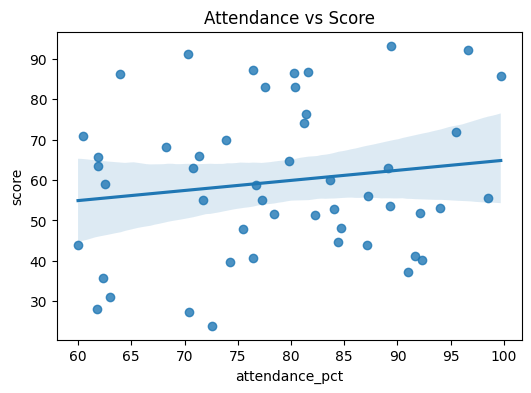

In [43]:
# Scatter plot 2

plt.figure(figsize=(6, 4))

sns.regplot(
    data=df,
    x='attendance_pct',
    y='score'
)

plt.title("Attendance vs Score")

plt.savefig("attendance_vs_score.png")

plt.show()

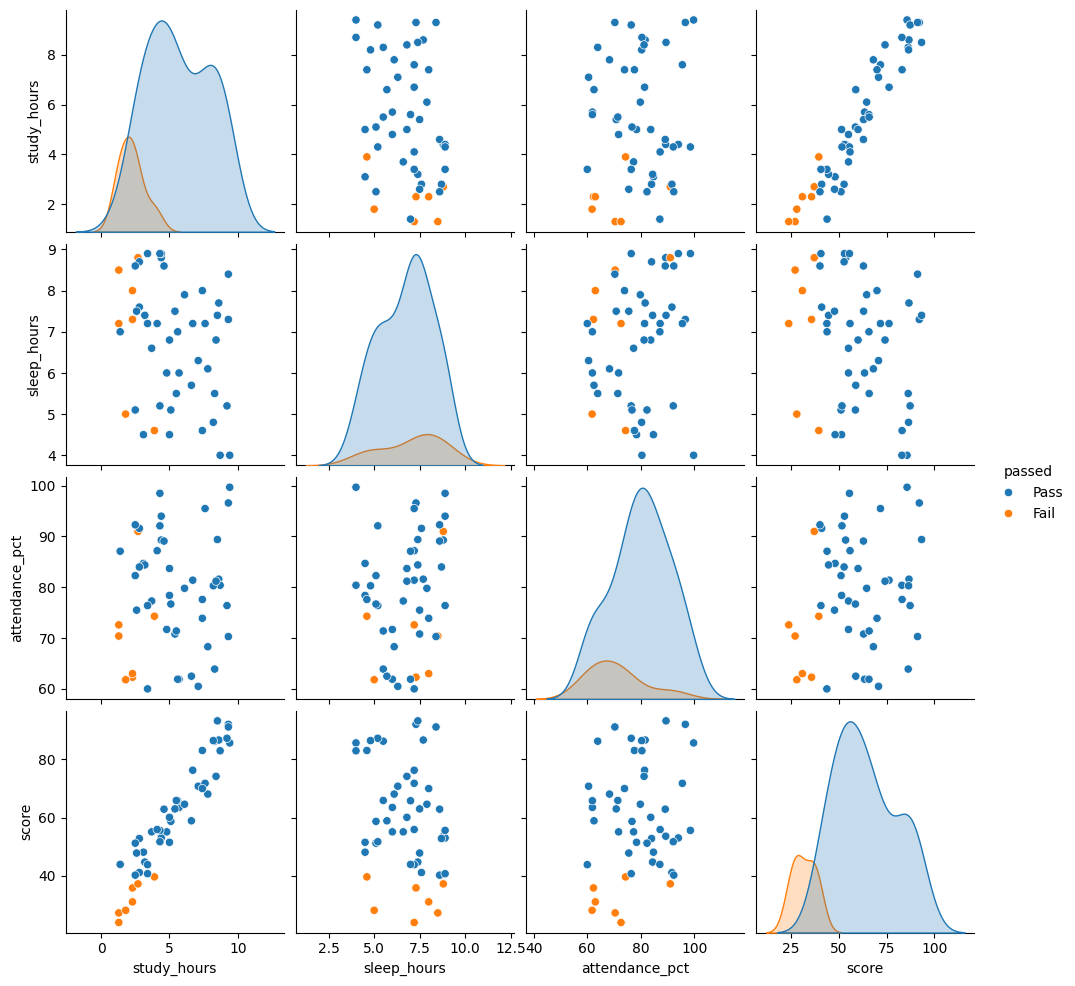

In [44]:
# Pairplot

sns.pairplot(
    df,
    hue='passed'
)

plt.savefig("pairplot.png")

plt.show()

In [45]:
# Final analysis

print("""

Analysis:

1. Students who study more generally score higher.

2. Attendance also positively affects score.

3. Sleep hours have weaker correlation with score.

4. Study hours do not always guarantee high score because noise/randomness was added.

5. Pairplot shows pass/fail students forming partial clusters.

""")



Analysis:

1. Students who study more generally score higher.

2. Attendance also positively affects score.

3. Sleep hours have weaker correlation with score.

4. Study hours do not always guarantee high score because noise/randomness was added.

5. Pairplot shows pass/fail students forming partial clusters.


